# SK Hynix ADR premium — access, financing, execution and monitoring

**A prime-finance note.** What the constraint is, how exposure to it can be expressed and
hedged, what it costs, what it risks, and what a desk would watch on a client's behalf.

---

> **Informational only.** This note is not investment advice, not a recommendation, and not
> a solicitation. It describes structures and their mechanics; it does not advise taking
> any position. All figures derive from public data or cited public sources. Levels marked
> *desk quotes live* are not published and would be quoted on request. Nothing here
> forecasts the premium beyond what a registered research call states, and those calls are
> named with their class and resolution date.

---

## Executive summary

**The situation, in four sentences.** SK Hynix listed ADRs on Nasdaq on 2026-07-10 at
US$149.00 (177.9m ADSs, 10 ADSs = 1 common share), and the ADR has traded persistently above
the underlying since — 15.98% to 51.60% in the first three weeks, 22.6% most recently. The
usual arbitrage does not close it, because the supply valve is asymmetric: **ADR→local
cancellation is a holder right, while local→ADR issuance requires the Company's prior
consent against a level it sets and does not disclose** (Deposit Agreement, F-6 Ex. 99(a)).
The board's 2.50% figure widely described as a "conversion quota" is in fact a cap on
*primary issuance*, sized so the controlling shareholder stays above a 20% statutory floor
under the Monopoly Regulation and Fair Trade Act. So the upper barrier is a corporate
decision entangled with a regulatory position — harder to lift than a quota.

**Expressions menu** — one live, four contingent on data this programme has not yet sourced.

| | Expression | Readiness | What it monetizes |
|---|---|---|---|
| 1 | Convergence RV (short ADR / long local, FX-hedged) | **live** | premium compression toward the conversion floor |
| 2 | Local-access substitute (index synthetic) | contingent | offshore demand for constrained local exposure |
| 3 | Term-structure RV | contingent | mispriced convergence *speed* |
| 4 | Volatility RV | contingent | ADR implied vol over the local+FX stack |
| 5 | Flow-aware execution overlay | contingent | slippage against mechanical rebalance flow |

**Cost.** The documented crossing cost is trivial — US$0.05 per ADS each way, **~0.07% of
price**. Borrow, funding and hedge points are not publicly documented and would be quoted
live. Cost is emphatically *not* what sustains this premium.

**Risk, in one sentence.** Every short-premium expression is short a barrier that exists on
only one side: gain is bounded by the conversion floor, loss is unbounded, and the premium
ran **from 15.98% to 51.60% in week one** — roughly 36 points against such a position
before any convergence.

**Monitoring.** The desk tracks the barrier-state observable daily (KSD headroom on the
capped programme), the premium under both measurement definitions, and a regulatory event
register. Current headroom reading appears in §5.

Research ledger: FROZEN 2026-07-29T05:20:00+00:00
  h1_term_structure      class X  status exploratory
  h2_index_access        class X  status exploratory
  h3_letf_loop           class X  status exploratory
  h4_vol_decomposition   class X  status exploratory
  h5_quota_ledger        class C  status frozen

Only Class C/P calls are registered. Class X are exploratory and are not
presented as pre-registered forward tests anywhere in this note.


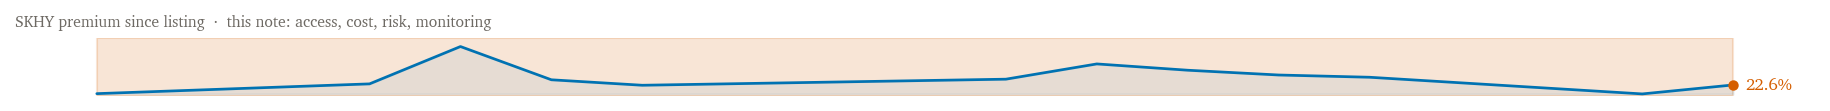

In [1]:
%matplotlib inline
import sys, pathlib, subprocess, yaml
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from pipeline.viz import theme
from pipeline.measurement.premium import build_all_variants
theme.apply()

calls = yaml.safe_load((ROOT/"preregistration"/"calls.yaml").read_text())
frozen = calls.get("frozen_at")
print(f"Research ledger: FROZEN {frozen}" if frozen else "Research ledger: NOT FROZEN")
for h, v in calls.items():
    if isinstance(v, dict) and "freeze_class" in v:
        print(f"  {h:22s} class {v['freeze_class']}  status {v['status']}")
print("\nOnly Class C/P calls are registered. Class X are exploratory and are not")
print("presented as pre-registered forward tests anywhere in this note.")

sk = build_all_variants("skhy")[0]
theme.sparkline_header(sk.series, highlight=("2026-07-10","2026-07-28"),
                       label="SKHY premium since listing  ·  this note: access, cost, risk, monitoring");

---

# §1 Situation

## 1.1 What the constraint actually is

Two documented facts define the asymmetry, and they are of different kinds.

**Downward — a right.** A holder may surrender ADSs and withdraw the underlying shares at
any time, subject only to transfer books, fees and law (17 CFR §239.36(a)). A programme
cannot use Form F-6 without granting it.

**Upward — a permission.** The deposit agreement requires the depositary to refuse shares
whenever a deposit *"would cause the total number of Shares deposited to exceed a level from
time to time determined by the Company"*, and the prospectus adds that the Company's prior
consent is required, noting plainly: *"It is possible that we may not give such consent."*

**No numeric deposit cap appears in any SEC filing.** The widely-quoted 2.50% is the board's
authorization for *primary issuance* — 17,790,000 shares — sized against the MRFTA
requirement that the controlling shareholder hold ≥20%; post-issuance it sits at 20.0008%.
Expanding the programme by primary issuance would dilute below a statutory floor.

*Interpretation.* Headroom on the deposit side is created only by prior cancellations. While
the ADR trades at a premium, no rational holder cancels — so no headroom appears — so the
premium is not arbitraged away. The premium removes the incentive to create the capacity
that would compress it.

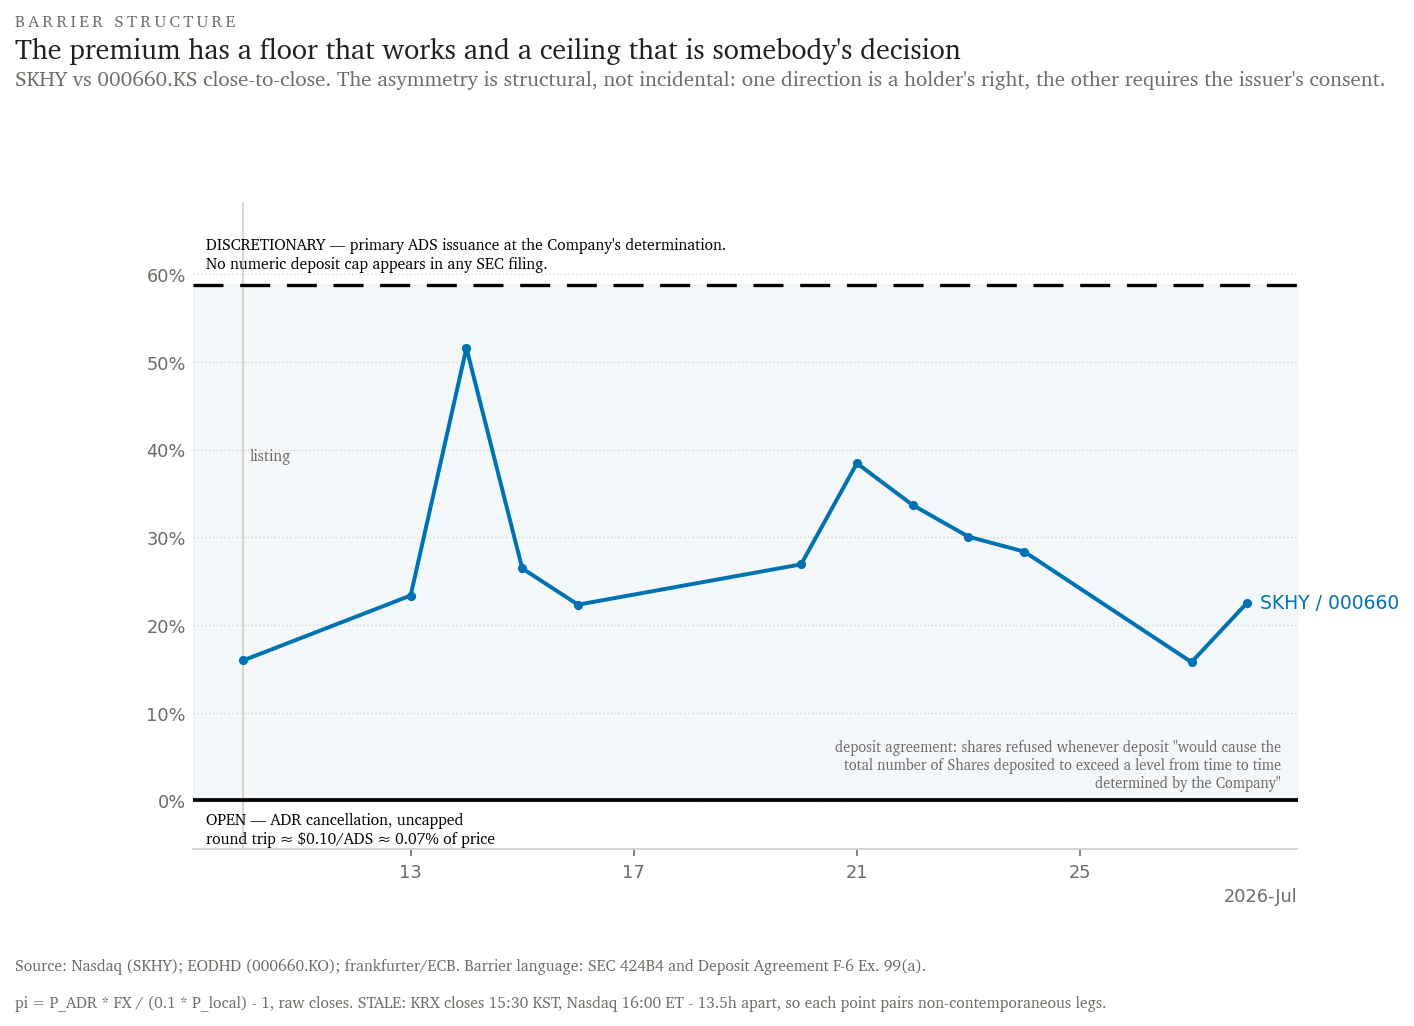

In [2]:
from pipeline.viz import figures
fig, ax = figures.g1_barrier_anatomy(sk.series, theme.events_for(markets=["US","KR"]))
fig;

**In plain terms**

- Hynix's US shares have been worth 16-52% more than the identical Korean shares since July.
  Normally that gap gets traded away in a day.
- It cannot be, because the trade only works one way. You can always turn a US share back into a
  Korean one. Going the other way needs the company's permission, and it has not given it.
- So the gap has a floor it cannot fall through and no ceiling it cannot rise above.

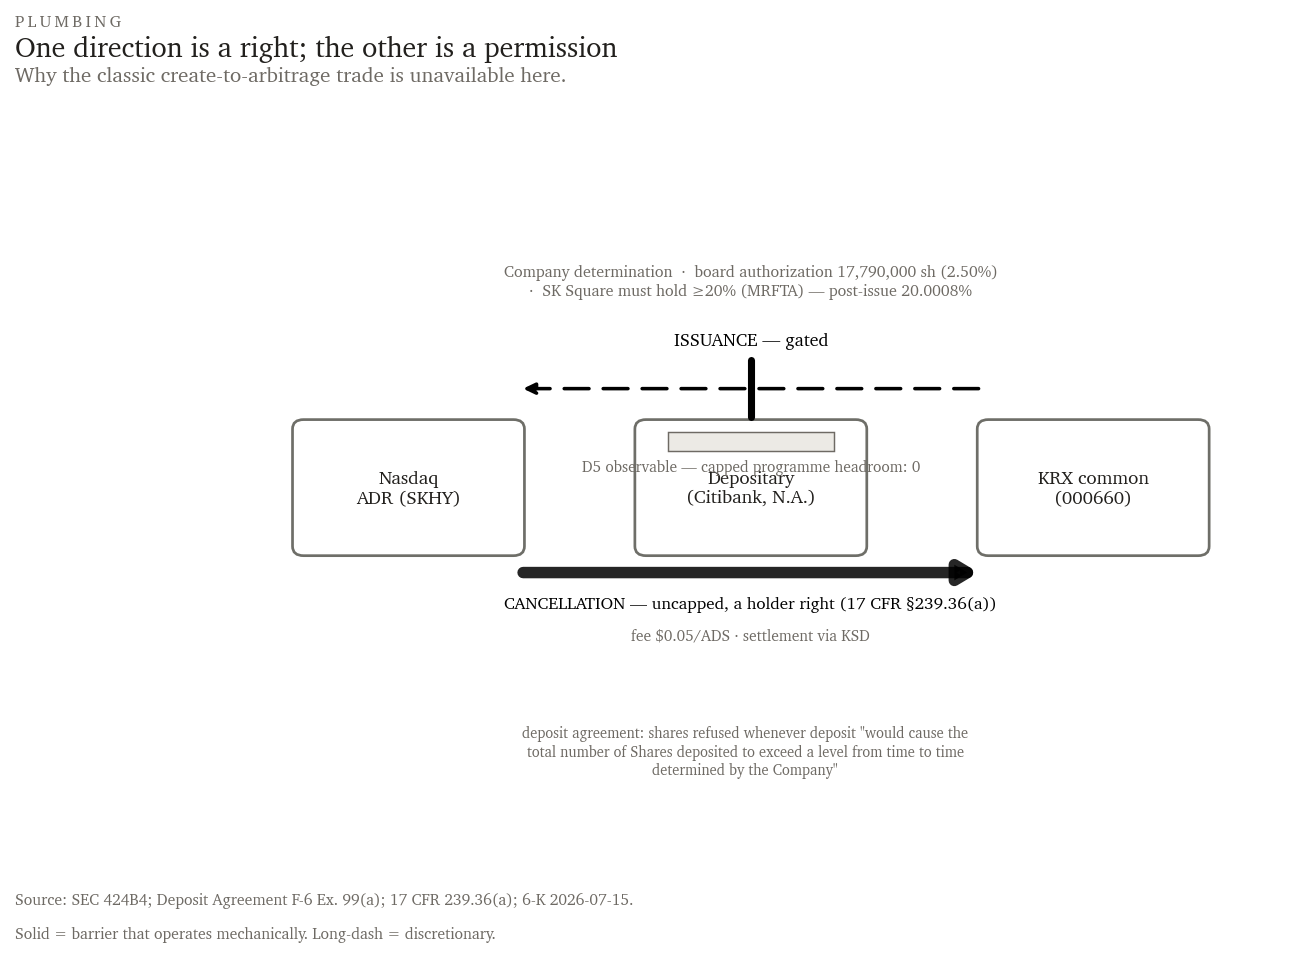

In [3]:
fig, ax = figures.g2_plumbing_map()
fig;

**In plain terms**

- Two pipes connect the US listing to the Korean one. The wide one always flows; the narrow one
  has a gate on it.
- The gate is not a rulebook number — it is a decision the company makes and does not publish.
  That is harder to plan around than a quota.
- Watch the gauge: it reads zero, meaning nothing is currently allowed through.

## 1.2 The comparator, and what it does not tell you

TSMC's ADR operates a structurally similar asymmetry, and its premium has persisted for a
decade — but its facility is explicitly **revolving**: its 20-F states issuance is
*"permitted to the extent that previously issued depositary receipts have been cancelled."*
That makes it a weaker analogue for a discretionary-consent barrier, while simultaneously
*strengthening* the persistence case: a premium that survives a working refill valve is more
evidence of durability, not less.

The 12.6% "five-year average" in circulation is untraceable to a primary source and is
contradicted by ~10% from the same provider a year earlier. This note does not use it. It
uses this programme's own reproducible measurement instead.

---

# §2 Expressions menu

Each sheet below states structure, hedge, residual exposures, cost, stress, constraints,
risk and the observable that monitors it.

**On the holding period, which every cost line accrues against.** The research programme now
measures it rather than extrapolating it, on a panel of four barrier-constrained pairs, and
the measurement has an unusual shape: the premium's half-life has a **floor at 95%, and no
upper bound.** The upper edge of the confidence band never reaches half-decay at any horizon
the data can estimate — so these data do not reject a premium that never halves. Financing
cost is linear in holding period. **It is therefore quoted as a floor, never as a point**, and
a financing line that can be withdrawn inside that floor is the binding risk on any
convergence expression. The current floor prints below, live from the estimate rather than
transcribed. §6 sets out what remains genuinely unquantified.

In [4]:
from pipeline.hedging.ratios import sizing_horizon
_h = sizing_horizon()
print(f"Holding period   : {_h['expected_holding_period']}")
print(f"  95% floor      : {_h['holding_period_floor_days']:.0f} trading days "
      f"(~{_h['holding_period_floor_days']/21:.0f} months)")
print(f"  first passage  : {_h['holding_period_point_days']:.0f} trading days   [{_h['support']}]")
print(f"  95% ceiling    : {'NONE — unbounded' if _h['holding_period_ceiling_days'] is None else _h['holding_period_ceiling_days']}")
print()
print(f"Financed cost    : {_h['financed_cost_over_horizon']}")

Holding period   : AT LEAST 220 trading days (~10 months); NO FINITE UPPER BOUND at 95%
  95% floor      : 220 trading days (~10 months)
  first passage  : 314 trading days   [interpolated]
  95% ceiling    : NONE — unbounded

Financed cost    : Quote as a FLOOR: (borrow + funding + hedge points) accrued over at least 220 trading days, with no upper bound. Cost is linear in horizon and the horizon's upper tail is open, so a point cost would misstate the risk in the direction that flatters the trade.


In [5]:
from pipeline.hedging.sheets import all_sheets
from pipeline.hedging.ratios import HedgeLegs, fx_hedge, fx_sensitivity
from pipeline.ingest._common import latest_raw_file
import pandas as pd

adr = pd.read_csv(latest_raw_file("d1_prices","skhy_adr_daily.csv")).iloc[-1]
loc = pd.read_csv(latest_raw_file("d1_prices","skhynix_local_daily.csv")).iloc[-1]
fxr = pd.read_csv(latest_raw_file("d1_prices","usdkrw_spot_daily.csv")).iloc[-1]
legs = HedgeLegs(float(adr.close), float(loc.close), float(fxr.close))

from hypotheses.h5_quota_ledger.monitor import ledger
cap = ledger()["capped"]
reading = f"headroom {cap.level:,} on {cap.isin} (obs {cap.n_obs}, last {cap.last_obs})"

sheets = all_sheets(legs.premium, reading)
print(sheets[0].render())

A. SHORT-SKHY FINANCING & MARGIN STRESS   [live]
STRUCTURE       Short 1 ADR (SKHY). Financing and margin treatment only -- this sheet prices CARRYING the position, not the view. Pair with the convergence RV sheet for the expression.
MONETIZES       Nothing on its own. It states what holding the short costs and what it posts under stress.

HEDGE
  - Not a hedge sheet. The FX and beta legs live on the convergence RV sheet; the residual premium notional it leaves unhedged (~18% of the ADR leg) is the quantity margined here.

RESIDUAL EXPOSURES (what the hedge does NOT cover)
  ! RECALL RISK is the binding one. The position must be financeable across the whole holding floor -- at least 220 trading days (~10 months); no finite upper bound at 95%. A borrow recalled inside that floor forces a close at whatever the premium is on the day, which converts a convergence view into a liquidation.
  ! Margin is marked to the OBSERVABLE premium, so the stress case is a realized excursion rather than 

### The hedge detail that matters most

A convergence position is **not FX-neutral even when the local leg is fully FX-hedged.** The
premium is itself a currency-exposed notional — the excess of ADR notional over local
notional — and it is the part a local-leg hedge does not cover.

In [6]:
h = fx_hedge(legs)
s = fx_sensitivity(legs.premium)
print(f"ADR leg notional            ${h['adr_leg_usd_notional']:,.2f}")
print(f"local leg (USD equivalent)  ${h['local_leg_usd_equivalent']:,.2f}")
print(f"RESIDUAL premium notional   ${h['residual_premium_notional_usd']:,.2f}"
      f"   = {h['residual_as_pct_of_adr_leg']:.1%} of the ADR leg, unhedged by a local-leg hedge")
print()
print(f"1% KRW depreciation widens the premium by:")
print(f"   analytic   {s['analytic_premium_change_pct_pts']}pp   (ceteris paribus)")
print(f"   empirical  {s['empirical_central_pct_pts']}pp   range {s['empirical_range_pct_pts']} (95% CI)")
print(f"   FX share of daily premium variance: {s['fx_share_of_daily_premium_variance']:.1%}")
print()
print("READ THIS CAREFULLY:", s['caveat'])

ADR leg notional            $130.17
local leg (USD equivalent)  $96.00
RESIDUAL premium notional   $34.17   = 26.2% of the ADR leg, unhedged by a local-leg hedge

1% KRW depreciation widens the premium by:
   analytic   1.356pp   (ceteris paribus)
   empirical  1.092pp   range (0.687, 1.496) (95% CI)
   FX share of daily premium variance: 1.2%

READ THIS CAREFULLY: Analytic coefficient is ceteris paribus. Empirically 0.805 (95% CI 0.507-1.103) because both equity legs carry strong negative FX betas that partly offset it. FX explains only 1.2% of daily premium variation — the link is real and correctly signed, but it is not the dominant daily risk.


**Two readings, and the second qualifies the first.** The mechanical link is real and
correctly signed — a short-premium position is structurally short KRW weakness, and a hedge
sized off the local leg alone leaves it uncovered. But empirically the coefficient is 0.805
(95% CI 0.51–1.10, so theory is not rejected but is imprecisely pinned), because both equity
legs carry strong negative FX betas that partly offset it. And **FX explains only ~1.2% of
daily premium variation** — hedging the currency does not turn this into a low-variance
position. It removes a real but secondary risk.

### Contingent expressions

The remaining four are shown with their contingency stated rather than omitted — a desk
that shows a client what it cannot yet price earns more trust than one that quietly drops it.

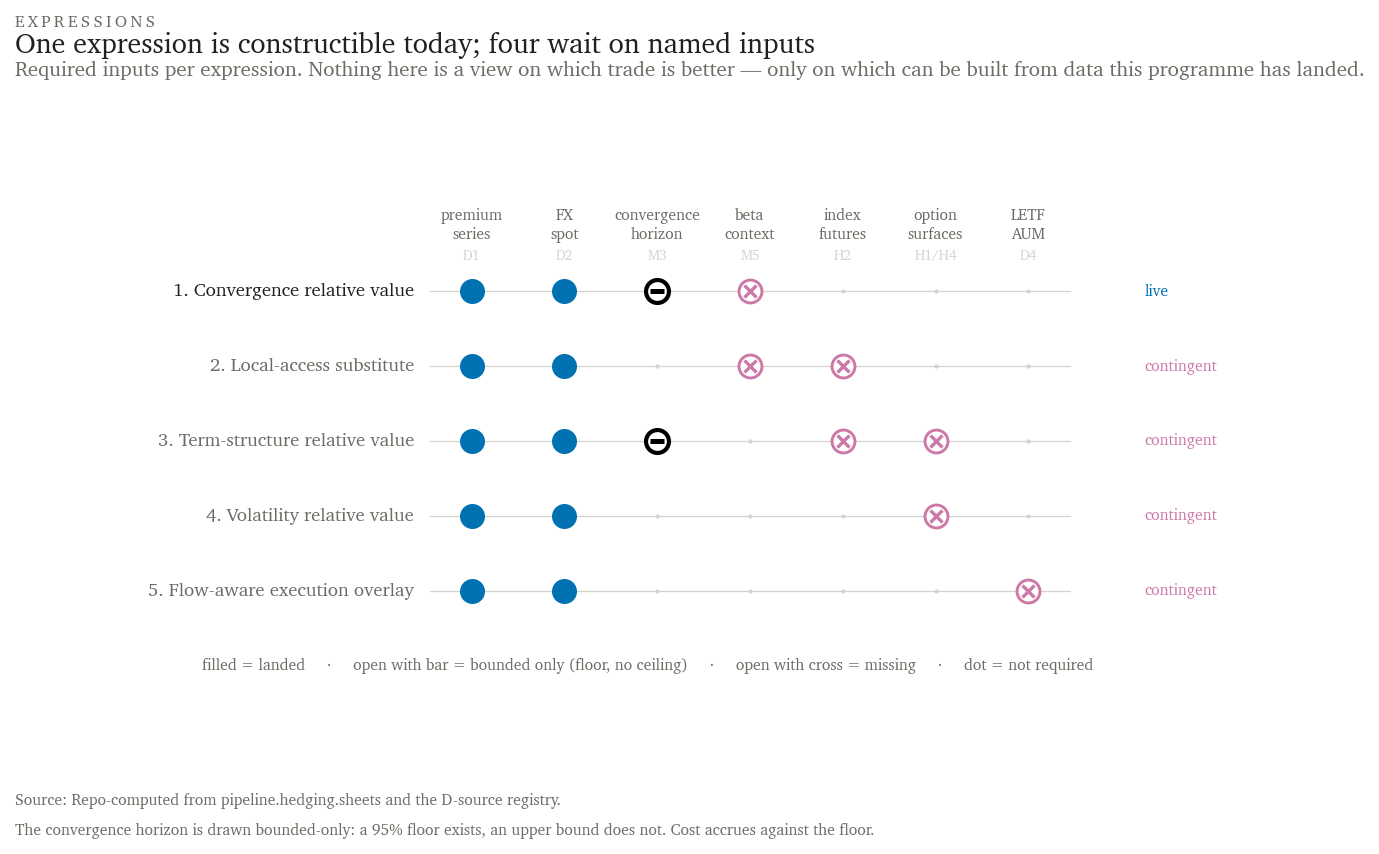

In [7]:
fig, ax = figures.g10_expression_readiness(sheets)
fig;

**In plain terms**

- Five ways to express this view. One can be built today; four wait on data we have not yet been
  able to buy or scrape.
- Two of the four need only a single missing input each, and both are purchasing problems rather
  than research problems.
- Nothing here says which trade is better — only which can be built honestly now.

Two of the four contingent expressions are a **single input** away. The volatility RV needs
only listed option surfaces for SKHY and 000660; the execution overlay needs only landed ETF
assets under management. Neither is a modelling gap — both are sourcing gaps, and both are
named in §6 with the route that would close them.

In [8]:
for sh in sheets[1:]:
    print(sh.render())
    print()

B. LONG-000660 ACCESS REGIME   [live]
STRUCTURE       Long 0.1 common shares (000660.KS) per ADR-equivalent. This sheet is about GETTING THE LEG ON as a non-resident, which is the part that actually gates the trade, not about the view.
MONETIZES       Nothing on its own. It is the access half of any convergence expression.

HEDGE
  - FX: sell KRW forward against the KRW notional. Tenor follows the holding floor, so the forward is a >=12m instrument, not a spot-adjacent one.

RESIDUAL EXPOSURES (what the hedge does NOT cover)
  ! SETTLEMENT MISMATCH. KRX settles T+2 and the ADR leg T+1, so a paired trade carries a one-day funding gap on every rebalance. Small per turn, not small over a 220-day floor.
  ! The premium notional itself stays FX-exposed even with this leg hedged -- see the convergence RV sheet's residual section.

COST STACK
  KRX transaction tax + fees         — desk quotes live —
  FX hedge (forward points)          — desk quotes live at >=12m tenor —
  custody / omnibus  

---

# §3 Costs and financing

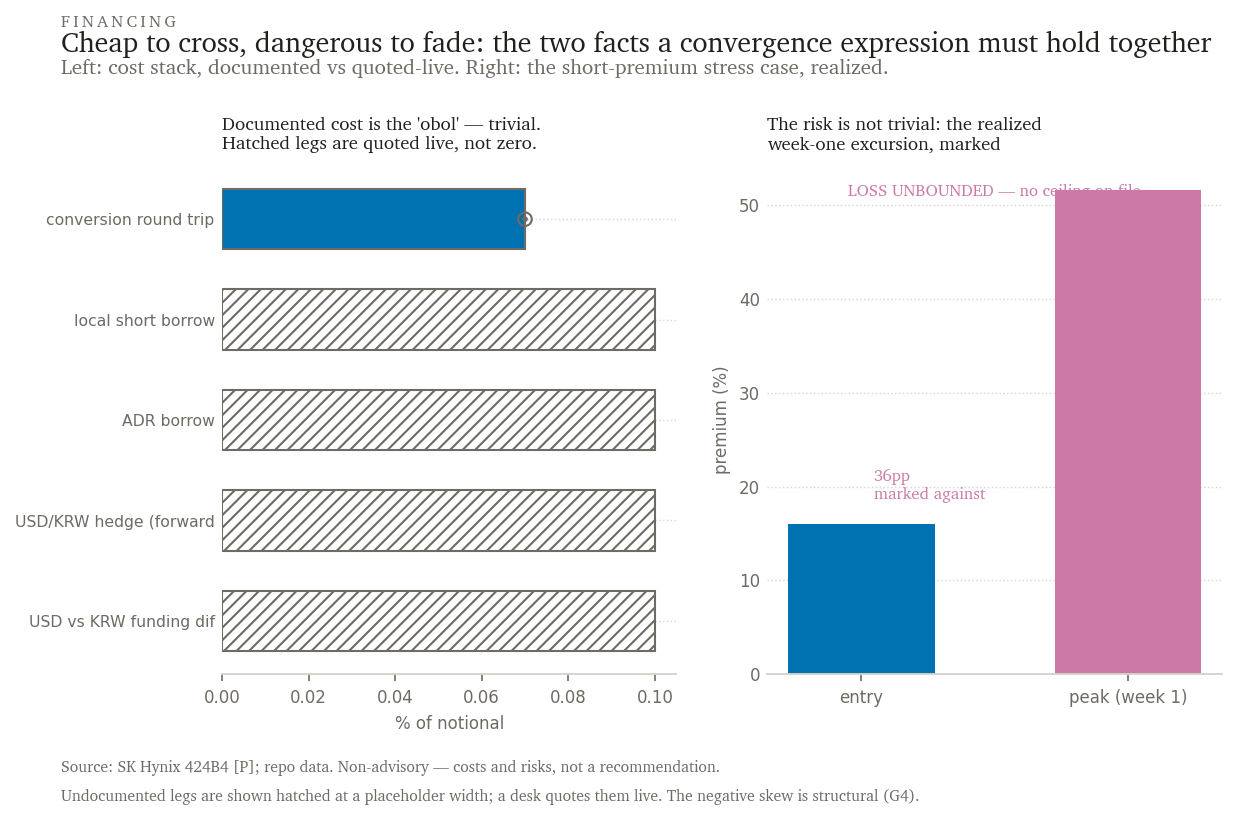

In [9]:
from execution.costs import summary_table, margin_stress
fig, axes = figures.g9_cost_and_skew(summary_table().to_dict("records"), margin_stress())
fig;

**In plain terms**

- The paperwork cost of the trade is trivial: about 7 basis points, round trip.
- The costs that matter — borrowing the shares, funding the position, hedging the currency — are
  not published. The desk quotes them live.
- Cost is not what keeps this gap open. Risk is.

The documented segment is the conversion round trip: **US$0.05 per ADS each way, ~0.07% of
price.** Every other segment — local borrow, ADR borrow, FX hedge points, funding
differential — is not publicly documented at usable granularity and is shown hatched. **The
desk quotes these live on request.** They are not zero, and this note does not estimate them.

Margin methodology, in sketch: the premium leg is marked to the observable premium, so the
stress case is the realized excursion in §4 rather than a modelled shock.

---

# §4 Risks

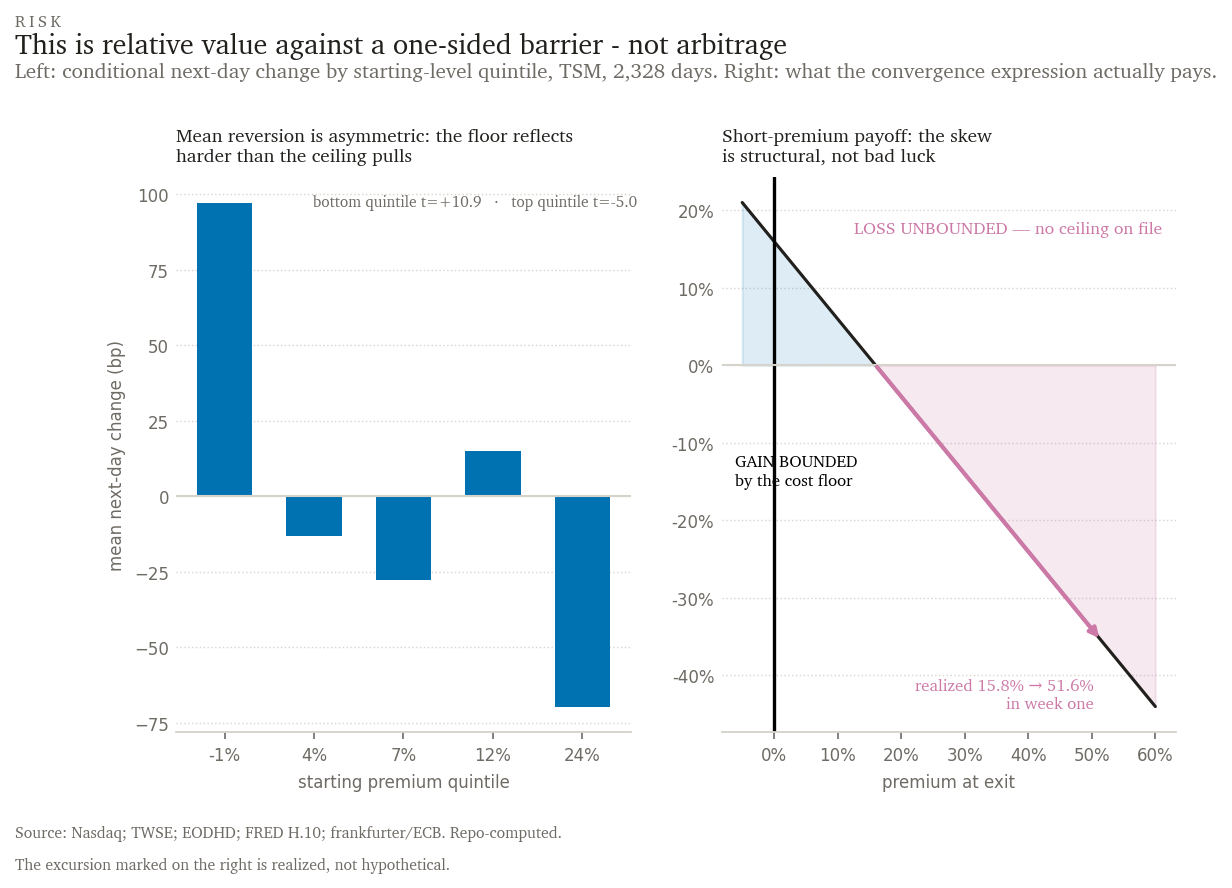

In [10]:
tsm = build_all_variants("tsmc")[0]
fig, axes = figures.g4_asymmetry(tsm.series, sk.series)
fig;

**In plain terms**

- Betting the gap closes pays a little if you are right and loses a lot if you are wrong. That is
  not bad luck, it is the shape of the trade.
- The most you can make is the gap you sold. The most you can lose has no limit, because nothing
  on file caps how wide it can get.
- It already ran from 16% to 52% in one week — about 36 points against that bet, before any of it
  came back.

**The skew is structural, not circumstantial.** Gain on a convergence expression is bounded
by the conversion floor; loss is unbounded because there is no numeric ceiling on file. The
left panel shows the comparator's mean reversion is *asymmetric* — the floor reflects far
harder (t = +10.9) than the ceiling pulls (t = −5.0).

**Other risks carried, each with its anchor:**

- **FX gap risk** on the residual premium notional (§2), which a local-leg hedge does not cover.
- **Short-sale regime change.** Korean short selling resumed 2025-03-31; Korea has twice
  responded to sharp declines with bans. Current status is inferred from the absence of a
  contrary notice — verify before relying on it.
- **Leveraged-ETF regulatory review.** New single-stock leveraged listings were suspended
  2026-07-16 and the deposit requirement raised, accelerated to 2026-07-31. Eligibility rules
  admit only two names, so this is concentrated in the underlying.
- **Upper-barrier corporate action.** Because the ceiling is a Company determination, it opens
  by *decision*, disclosable through Korean regulatory filings. This is a monitorable event
  class, not a market variable — and it is the single event that would most change the thesis.
- **Measurement risk.** Two things, and only one is understood. The **FX fix choice** moves
day-over-day premium changes by ~27bp on average — measured, and the reason this note uses the
ECB reference rate. Separately, a **24.6bp cross-source disagreement** was observed in one
session between a recorded figure and two providers' prints; close definition is the leading
hypothesis and is **untested**, because only one close series per leg is landed. Reported as
unexplained rather than attributed.

---

# §5 Monitoring — what the desk watches

Presented as a service a client would receive: four observables, refreshed daily from public
sources, each with its current reading and its known limitation.

In [11]:
from hypotheses.h5_quota_ledger.monitor import status_report
print(status_report())

H5 — BARRIER-STATE LEDGER
skhynix_dr_headroom_capped  (US78392B2060)
  observations : 1   2026-07-15 .. 2026-07-15
  headroom     : 0
  flow         : no movement observed — level has never changed in sample
  ! headroom is ZERO — the barrier reads SEALED at this observation.
  ! single observation: KSD appears to publish only on change, so this is consistent with 'has not moved' rather than 'not published'. The control programme distinguishes the two.

skhynix_dr_headroom_legacy  (US78392B1070)
  observations : 1260   2010-03-31 .. 2026-07-28
  headroom     : 129,711,611
  flow         : 502 creation(s), 757 consumption(s)
  latest move  : +590

PUBLICATION CHECK
  PUBLISHING — control printed to 2026-07-28 while the capped programme's last print is 2026-07-15. The feed is live, so the capped programme has NOT MOVED. Barrier remains sealed by observation, not by absence of data.

CONTROL-PROGRAMME EPISODES ≥0.25% of level: 33

----------------------------------------------------------

**The publication check is the substantive line.** The capped programme has not printed since
2026-07-15, which alone is ambiguous between *the barrier has not moved* and *the feed is
silent*. The legacy programme — a different, unconstrained channel carried purely as a
control — printed through 07-28. So the feed is live and **the barrier is sealed by
observation, not by absence of data.**

**And the scope limit, stated because it changes what the signal means:** this series measures
a programme's issuance-ceiling headroom, **not** the operative consent gate. Headroom can rise
via cancellation while deposits remain blocked by consent never granted. The registered
research call is scoped accordingly, with an explicit indeterminate branch.

Also monitored: the premium under both close definitions and both FX fixes; estimated LETF
rebalance flow (**currently unavailable** — no landed AUM); and the regulatory event register.

---

# §6 Methodology and what is pending

Full research programme: **[00 — executive pitch](00_executive_pitch.ipynb)** ·
**[02 — premium anatomy](02_premium_anatomy.ipynb)** ·
**[05 — hypothesis engines](05_hypothesis_engines.ipynb)**. Sources:
`docs/research_notes.md` (57 sources, 40 primary).

**Pending quantitative fields and what fills them:**

| Field | Fills from | Why not yet |
|---|---|---|
| Upper bound on holding period | — | **none exists at 95%**, and roughly four times the data did not produce one. ρ's upper band never crosses ½ at any estimable horizon, so the floor is quoted instead |
| Independent regulatory variation | a constrained pair outside Taiwan | the four pooled pairs share one regulator, so they reduce issuer noise but not rule uncertainty. India was the obvious candidate; its headroom regime was repealed effective 15 Dec 2014 |
| Financed cost over horizon | linear in the above | inherits the same gate |
| Beta hedge ratio + interval | M5 single-name context layer | M5 not built; no Korea index proxy landed |
| FX hedge points | SGX curve at the horizon tenor | tenor follows the holding period; deferred SGX months are exchange-marked, not executable |
| LETF flow estimate | D4 issuer AUM | issuer pages are JS SPAs; the data-bearing route is terms-withheld |

**What is usable now, and robust:** the persistence contrast, now on four barrier-constrained
pairs rather than one — ρ₁ ≈ 0.98 pooled across 15,853 observations, against 0.04
(insignificant) for the fungible control, with per-pair ρ₁ running 0.82 to 0.99 so the result
replicates rather than resting on a single issuer. Under it sits a **measured floor** on the
convergence horizon rather than an assumption. The premium mean-reverts slowly; it must be
financeable for the floor printed above, and possibly indefinitely. That is the fact this note
relies on, and it is the fact a financing conversation should start from.

---

> **Informational only.** Not investment advice, not a recommendation, not a solicitation.
> The desk provides access, financing, execution and monitoring; it does not recommend
> positions. Levels marked *desk quotes live* are quoted on request. Public data throughout;
> figures reproducible from this repository.